In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [ ]:
faces= fetch_lfw_people(min_faces_per_person=70, resize= 0.4)

In [ ]:
x= faces.data
y= faces.target
nombres= faces.target_names
h,w = faces.images.shape[1:]

In [ ]:
print(nombres)
print(len(nombres))
print((h,w))
print(x.shape[0])

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']
7
(50, 37)
1288


In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
model= SVC(kernel='linear', class_weight='balanced')
model.fit(x_train, y_train)

SVC(class_weight='balanced', kernel='linear')

In [ ]:
y_pred= model.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names= nombres))

0.8527131782945736
                   precision    recall  f1-score   support

     Ariel Sharon       0.67      0.73      0.70        11
     Colin Powell       0.77      0.91      0.83        47
  Donald Rumsfeld       0.68      0.77      0.72        22
    George W Bush       0.95      0.88      0.92       119
Gerhard Schroeder       0.78      0.95      0.86        19
      Hugo Chavez       1.00      0.69      0.82        13
       Tony Blair       0.87      0.74      0.80        27

         accuracy                           0.85       258
        macro avg       0.82      0.81      0.81       258
     weighted avg       0.87      0.85      0.85       258



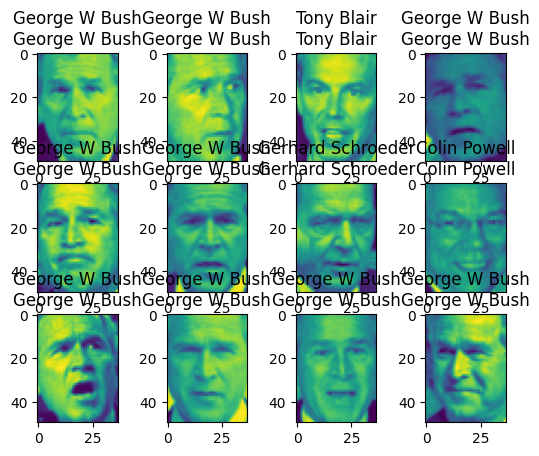

In [ ]:
for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(x_test[i].reshape(50,37))
  plt.title(str(faces.target_names[y_test[i]])+'\n'+str(faces.target_names[y_pred[i]]))